# 07_combined_analysis.ipynb
**Author:** Riley Ramos  
**Date:** 2025  
**Description:** Cross-hypothesis combined analysis for the Las Vegas urban sprawl thesis. Produces (1) a correlation matrix heatmap across all key variables, (2) a kitchen-sink OLS regression of all predictors on sprawl, and (3) a PCA-based equity burden score combining sprawl and socioeconomic indicators.  

**Input:** `data/processed/thesis_data.xlsx`  
- sheet: `sprawl_index`  
- sheet: `demographics`  
- sheet: `commute_duration`  
- sheet: `mean_travel_time`  
- sheet: `occupation`  
- sheet: `occupation_salary`  
- sheet: `PM25_concentrations`  
- sheet: `poverty`

**Output:**  
- Correlation matrix heatmap (Figure in thesis)  
- OLS regression summary (console)  
- LaTeX regression table (console)  
- `data/processed/burden_score.csv`

## Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from functools import reduce
from pathlib import Path

In [ ]:
# Global options
pd.options.display.float_format = '{:.6f}'.format

# Path to processed workbook — relative to project root
# If running from a subdirectory, adjust accordingly
DATA = Path("data/processed/thesis_data.xlsx")

---
## Section 1: Load Raw Sheets

In [6]:
# Sprawl index
sprawl = pd.read_excel(DATA, sheet_name='sprawl_index', dtype={'census_tract': str})

# Full demographics sheet (used for race/income and poverty derivations)
demogs = pd.read_excel(DATA, sheet_name='demographics', dtype={'census_tract': str})

# Commute duration (long-format: transportation_type, commute_length, count)
commute = pd.read_excel(DATA, sheet_name='work_commute_time', dtype={'census_tract': str})

# Mean travel time per census tract
mean_travel = pd.read_excel(DATA, sheet_name='mean_travel_time', dtype={'census_tract': str})

# Occupation counts (mgmt_pop, service_pop, etc.)
occupation = pd.read_excel(DATA, sheet_name='occupation', dtype={'census_tract': str})

# Occupation median salaries
salary = pd.read_excel(DATA, sheet_name='occupation_salary', dtype={'census_tract': str})
# 'total' column = overall median earnings across all occupations
salary = salary.rename(columns={'total': 'avg'})

# PM2.5 air pollution concentrations
pm25 = pd.read_excel(DATA, sheet_name='PM25_concentrations', dtype={'census_tract': str})

# Poverty levels
poverty = pd.read_excel(DATA, sheet_name='poverty', dtype={'census_tract': str})

print("Sheets loaded successfully.")

Sheets loaded successfully.


---
## Section 2: Derive Analysis-Ready Datasets

In [7]:
# --- 2a. Race + Income -------------------------------------------------------
# Compute % POC and scale median income to thousands (consistent with R scripts)

demogs['total_population'] = pd.to_numeric(
    demogs['total_population'].astype(str).str.replace(',', ''), errors='coerce')
demogs['white_population'] = pd.to_numeric(
    demogs['white_population'].astype(str).str.replace(',', ''), errors='coerce')
demogs['poc_population'] = pd.to_numeric(
    demogs['poc_population'].astype(str).str.replace(',', ''), errors='coerce')
demogs['median_income'] = pd.to_numeric(
    demogs['median_income'].astype(str).str.replace(',', ''), errors='coerce')

race_income = demogs[['census_tract', 'total_population', 'white_population',
                       'poc_population', 'median_income']].copy()
race_income['perc_poc']      = (race_income['poc_population'] / race_income['total_population']) * 100
race_income['median_income'] = race_income['median_income'] / 1000
race_income = race_income[['census_tract', 'median_income', 'perc_poc']]

print(race_income.head())

  census_tract  median_income  perc_poc
0       000101      22.985000 72.819990
1       000103      22.085000 74.952594
2       000105      25.727000 55.707039
3       000106      22.473000 54.486462
4       000107      23.627000 67.436548


In [8]:
# --- 2b. Commute classification (long vs. short) -----------------------------
# Classifies tracts by whether majority of commuters travel >= 30 minutes.
# Uses the commute_duration sheet (long format).

commute['count'] = pd.to_numeric(
    commute['count'].astype(str).str.replace(',', ''), errors='coerce')

# Total commuters per tract (all transportation methods, Total time interval)
total_commuters = (
    commute[
        (commute['transportation_type'] == 'All transportation methods') &
        (commute['commute_length'] == 'Total')
    ]
    [['census_tract', 'count']]
    .rename(columns={'count': 'total_pop'})
)

# Long commute = 30 or more minutes
long_labels = ['30 to 34 minutes', '35 to 44 minutes', '45 to 59 minutes',
               '60 or more minutes']

long_commute = (
    commute[
        (commute['transportation_type'] == 'All transportation methods') &
        (commute['commute_length'].isin(long_labels))
    ]
    .groupby('census_tract')['count'].sum()
    .reset_index()
    .rename(columns={'count': 'long_count'})
)

commute_class = total_commuters.merge(long_commute, on='census_tract', how='inner')
commute_class['total_perc_long']  = commute_class['long_count'] / commute_class['total_pop']
commute_class['total_perc_short'] = 1 - commute_class['total_perc_long']
commute_class['commute_class']    = commute_class['total_perc_long'].apply(
    lambda x: 'long' if x >= 0.5 else 'short'
)
# Scale to percentages
commute_class['total_perc_long']  = commute_class['total_perc_long']  * 100
commute_class['total_perc_short'] = commute_class['total_perc_short'] * 100
commute_class = commute_class[['census_tract', 'total_perc_long', 'total_perc_short', 'commute_class']]

print(commute_class.head())

  census_tract  total_perc_long  total_perc_short commute_class
0       000101        23.953766         76.046234         short
1       000103        40.206976         59.793024         short
2       000105        38.550136         61.449864         short
3       000106        28.333333         71.666667         short
4       000107        19.828968         80.171032         short


In [9]:
# --- 2c. Car vs. other transportation percentage -----------------------------
# Aggregates commute counts into car and other modes per tract.
# Mirrors the logic in 04_hypothesis_3.R Section 3.

# Total commuters (denominator)
total_all = (
    commute[
        (commute['transportation_type'] == 'All transportation methods') &
        (commute['commute_length'] == 'Total')
    ]
    [['census_tract', 'count']]
    .rename(columns={'count': 'total_pop'})
)

# Exclude the 'All transportation methods' row; classify car vs. other
transpo = commute[
    (commute['commute_length'] == 'Total') &
    (commute['transportation_type'] != 'All transportation methods')
].copy()

transpo['mode'] = transpo['transportation_type'].apply(
    lambda x: 'car' if 'Car' in str(x) or 'car' in str(x) else 'other'
)

transpo_grouped = (
    transpo.groupby(['census_tract', 'mode'])['count']
    .sum()
    .reset_index()
)

transpo_wide = transpo_grouped.pivot(index='census_tract', columns='mode', values='count').reset_index()
transpo_wide = transpo_wide.merge(total_all, on='census_tract', how='inner')
transpo_wide['car_perc']   = (transpo_wide['car']   / transpo_wide['total_pop']) * 100
transpo_wide['other_perc'] = (transpo_wide['other'] / transpo_wide['total_pop']) * 100
transpo_wide = transpo_wide[['census_tract', 'car_perc', 'other_perc']]

print(transpo_wide.head())

  census_tract  car_perc  other_perc
0       000101 96.253487    3.746513
1       000103 83.671905   16.328095
2       000105 83.672087   16.327913
3       000106 94.611111    5.388889
4       000107 82.576162   17.423838


In [10]:
# --- 2d. Management and service occupation percent + salary ------------------
# Computes mgmt_percent and service_perc from occupation counts,
# and extracts mgmt_salary and service_salary from occupation_salary.

occ_cols = ['census_tract', 'employed_pop', 'mgmt_pop', 'service_pop']
occ = occupation[occ_cols].copy()
for col in ['employed_pop', 'mgmt_pop', 'service_pop']:
    occ[col] = pd.to_numeric(occ[col].astype(str).str.replace(',', ''), errors='coerce')

occ['mgmt_percent'] = (occ['mgmt_pop']    / occ['employed_pop']) * 100
occ['service_perc'] = (occ['service_pop'] / occ['employed_pop']) * 100
occ = occ[['census_tract', 'mgmt_percent', 'service_perc']]

sal_cols = ['census_tract', 'mgmt_med_salary', 'service_med_salary']
sal = salary[sal_cols].copy()
for col in ['mgmt_med_salary', 'service_med_salary']:
    sal[col] = pd.to_numeric(sal[col].astype(str).str.replace(',', ''), errors='coerce') / 1000
sal = sal.rename(columns={'mgmt_med_salary': 'mgmt_salary', 'service_med_salary': 'service_salary'})

mgmt = occ[['census_tract', 'mgmt_percent']].merge(
    sal[['census_tract', 'mgmt_salary']], on='census_tract', how='inner')
service = occ[['census_tract', 'service_perc']].merge(
    sal[['census_tract', 'service_salary']], on='census_tract', how='inner')

print(mgmt.head())
print(service.head())

  census_tract  mgmt_percent  mgmt_salary
0       000101     20.447648    26.881000
1       000103      5.499439    36.466000
2       000105     13.689700    43.879000
3       000106     16.917293    38.147000
4       000107      9.343832    50.952000
  census_tract  service_perc  service_salary
0       000101     39.567527       25.084000
1       000103     43.247288       22.780000
2       000105     33.050847       21.644000
3       000106     31.364125       25.795000
4       000107     54.960630       28.817000


In [14]:
poverty

,census_tract,total_pop,poverty_total,low_income_total,income_marg_perc
0,000101,5883,978,668,27.978922
1,000103,5801,1023,895,33.063265
2,000105,3154,396,31,13.538364
3,000106,4458,615,340,21.422162
4,000107,3940,240,264,12.791878
...,...,...,...,...,...
474,007100,3064,651,735,45.234987
475,007200,3748,465,252,19.130203
476,007500,1495,226,128,23.678930
477,007600,3877,545,527,27.650245


In [15]:
# --- 2e. Poverty / income marginalization ------------------------------------
# Computes income_marg_perc = (poverty + near-poverty) / total population.
# Source columns from the demographics sheet.

poverty_cols = [
    'census_tract',
    'total_pop',
    'poverty_total',
    'low_income_total'
]
poverty = poverty[poverty_cols].copy()

for col in ['total_pop', 'poverty_total', 'low_income_total']:
    poverty[col] = pd.to_numeric(
        poverty[col].astype(str).str.replace(',', ''), errors='coerce')

poverty['income_marg_perc'] = (
    (poverty['poverty_total'] + poverty['low_income_total']) / poverty['total_pop']
) * 100

# Keep only tracts that appear in the sprawl dataset
poverty_sprawl = poverty.merge(sprawl[['census_tract']], on='census_tract', how='inner')
poverty_sprawl = poverty_sprawl[['census_tract', 'income_marg_perc']]

print(poverty_sprawl.describe())

       income_marg_perc
count        465.000000
mean          20.431513
std           14.341301
min            0.000000
25%           10.000000
50%           15.897436
75%           28.352881
max           88.065844


---
## Section 3: Merge All Datasets

In [16]:
# Merge all derived datasets on census_tract
all_dfs = [sprawl, race_income, commute_class, mean_travel,
           transpo_wide, mgmt, service, pm25]

merged = reduce(
    lambda left, right: pd.merge(left, right, on='census_tract', how='inner'),
    all_dfs
)

# Drop columns not needed for correlation matrix or OLS
merged = merged.drop(columns=[
    'commute_class', 'census_tract',
    'max_PM_pred', 'min_PM_pred', 'sum_PM_pred',
    'total_perc_short', 'mgmt_salary', 'service_salary',
    'other_perc', 'total_perc_long'
], errors='ignore')

print(merged.columns.tolist())
print(merged.shape)

['sprawl_index', 'median_income', 'perc_poc', 'avg_work_commute_mins', 'car_perc', 'mgmt_percent', 'service_perc', 'avg_PM_pred']
(465, 8)


---
## Section 4: Correlation Matrix (Thesis Figure)

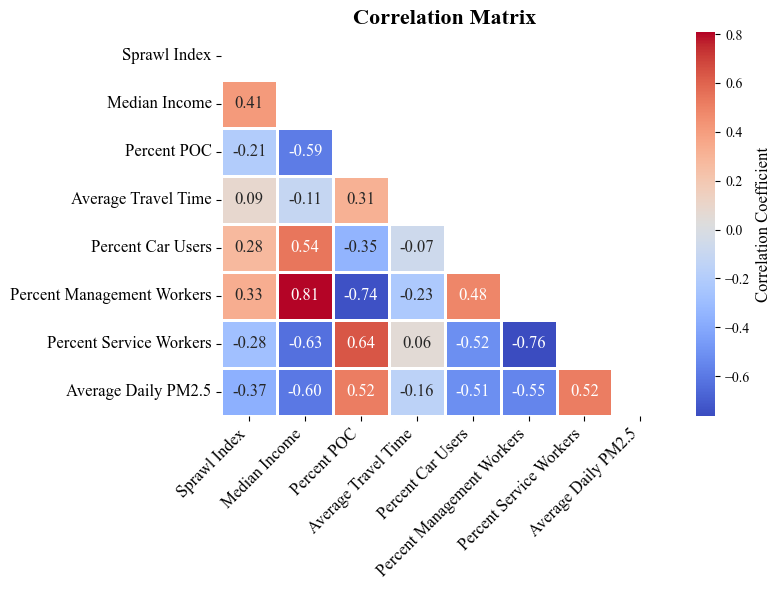

In [17]:
# Compute lower-triangle correlation matrix
corr_matrix = merged.corr()
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
corr_matrix[mask] = np.nan

labels = [
    'Sprawl Index', 'Median Income', 'Percent POC',
    'Average Travel Time', 'Percent Car Users',
    'Percent Management Workers', 'Percent Service Workers',
    'Average Daily PM2.5'
]

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    annot_kws={"fontsize": 12, "fontname": "Times New Roman"},
    cbar_kws={'label': 'Correlation Coefficient'},
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.75
)
plt.title('Correlation Matrix', fontname='Times New Roman', fontsize=16, fontweight='bold')
ax.set_xticklabels(labels, fontsize=12, fontname='Times New Roman', ha='right', rotation=45)
ax.set_yticklabels(labels, fontsize=12, fontname='Times New Roman')

colorbar = ax.collections[0].colorbar
colorbar.ax.yaxis.label.set_size(12)
colorbar.ax.yaxis.label.set_fontname('Times New Roman')
colorbar.ax.tick_params(labelsize=10)
for label in colorbar.ax.get_yticklabels():
    label.set_fontname('Times New Roman')

plt.tight_layout()
plt.show()

---
## Section 5: Sprawl in Car-dominant vs. Non-car-dominant Tracts T-Test (Table 7)

In [ ]:
# Car-dominant = > 50% of commuters use a car

transpo_classified = transpo_wide.merge(sprawl, on='census_tract', how='inner')
transpo_classified['car_dominant'] = transpo_classified['car_perc'] > 50

car_dominant     = transpo_classified[transpo_classified['car_dominant']]['sprawl_index']
non_car_dominant = transpo_classified[~transpo_classified['car_dominant']]['sprawl_index']

t_stat, p_value = stats.ttest_ind(car_dominant, non_car_dominant)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

T-statistic: 3.8038
P-value:     0.0002


---
## Section 6: Kitchen-Sink OLS Regression (Thesis)

In [23]:
# OLS: sprawl_index ~ all hypothesis variables
X = merged[['median_income', 'perc_poc', 'avg_work_commute_mins',
            'car_perc', 'mgmt_percent', 'service_perc', 'avg_PM_pred']]
y = merged['sprawl_index']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())
print("\nRMSE:", np.sqrt(model.mse_resid))

                            OLS Regression Results                            
Dep. Variable:           sprawl_index   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     17.08
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           4.24e-20
Time:                        20:28:46   Log-Likelihood:                -1761.0
No. Observations:                 465   AIC:                             3538.
Df Residuals:                     457   BIC:                             3571.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    43.48

In [24]:
# LaTeX regression table output
results_table = summary_col(
    model,
    stars=True,
    info_dict={
        'R-squared':        lambda x: f"{x.rsquared:.2f}",
        'No. observations': lambda x: f"{int(x.nobs)}"
    }
)
print(results_table.as_latex())

\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{ll}
\hline
                         & sprawl\_index  \\
\hline
const                    & 43.4803**      \\
                         & (17.5391)      \\
median\_income           & 0.4106***      \\
                         & (0.0999)       \\
perc\_poc                & 0.0553         \\
                         & (0.0396)       \\
avg\_work\_commute\_mins & 0.2314         \\
                         & (0.1450)       \\
car\_perc                & 0.0386         \\
                         & (0.0722)       \\
mgmt\_percent            & 0.0454         \\
                         & (0.0887)       \\
service\_perc            & -0.0093        \\
                         & (0.0842)       \\
avg\_PM\_pred            & -3.8202***     \\
                         & (1.3484)       \\
R-squared                & 0.2074         \\
R-squared Adj.           & 0.1953         \\
R-squared                & 0.21           \\
No. observations 

---
## Section 7: Equity Burden Score via PCA (Thesis)

In [35]:
# Build full merged dataset including poverty and census_tract identifier
all_dfs_full = [sprawl, race_income, commute_class, poverty,
                mean_travel, transpo_wide, mgmt, service, pm25]

new_merged = reduce(
    lambda left, right: pd.merge(left, right, on='census_tract', how='inner'),
    all_dfs_full
)
new_merged = new_merged.drop(columns=[
    'commute_class', 'max_PM_pred', 'min_PM_pred', 'sum_PM_pred',
    'total_perc_short', 'mgmt_salary', 'service_salary',
    'other_perc', 'total_perc_long'
], errors='ignore')

print(new_merged.head(5))

  census_tract  sprawl_index  median_income  perc_poc  total_pop  \
0       000101     36.903714      22.985000 72.819990       5883   
1       000103     24.527943      22.085000 74.952594       5801   
2       000105     28.821625      25.727000 55.707039       3154   
3       000106     26.000751      22.473000 54.486462       4458   
4       000107     25.410707      23.627000 67.436548       3940   

   poverty_total  low_income_total  income_marg_perc  avg_work_commute_mins  \
0            978               668         27.978922              21.800000   
1           1023               895         33.063265              24.100000   
2            396                31         13.538364              28.500000   
3            615               340         21.422162              22.100000   
4            240               264         12.791878              21.700000   

   car_perc  mgmt_percent  service_perc  avg_PM_pred  
0 96.253487     20.447648     39.567527     9.193350  
1 83.6

In [36]:
# Filter to high-burden tracts: majority POC or high poverty rate
filtered = new_merged[
    (new_merged['perc_poc'] > 50) | (new_merged['income_marg_perc'] > 30)
].copy()

print(f"High-burden tracts: {len(filtered)} of {len(new_merged)}")

High-burden tracts: 228 of 465


In [38]:
# PCA on outcome variables for filtered (high-burden) tracts
# Excludes demographic controls; captures multi-dimensional burden
outcome_cols = ['sprawl_index', 'avg_work_commute_mins', 'car_perc',
                'mgmt_percent', 'service_perc', 'avg_PM_pred']

pca = PCA()
data_scaled_filtered = StandardScaler().fit_transform(filtered[outcome_cols])
pca_scores = pca.fit_transform(data_scaled_filtered)
filtered['pc1'] = pca_scores[:, 0]

print(filtered['pc1'].describe())

count   228.000000
mean      0.000000
std       1.676502
min      -4.090983
25%      -1.176297
50%       0.051728
75%       1.283743
max       4.892845
Name: pc1, dtype: float64


In [39]:
# Apply fitted PCA to all tracts to produce a valley-wide burden score
data_scaled_all = StandardScaler().fit_transform(new_merged[outcome_cols])
new_merged['burden_score'] = pca.transform(data_scaled_all)[:, 0]

# Shift so minimum = 0 (score is relative, not absolute)
min_score = abs(new_merged['burden_score'].min())
new_merged['burden_score'] = new_merged['burden_score'] + min_score

print(new_merged['burden_score'].describe())
print(new_merged.sort_values('burden_score', ascending=False).head(10))

count   465.000000
mean      3.948969
std       1.697157
min       0.000000
25%       2.727904
50%       3.811193
75%       5.137520
max      10.063564
Name: burden_score, dtype: float64
   census_tract  sprawl_index  median_income  perc_poc  total_pop  \
33       000700      7.042570      11.481000 61.362608       1184   
40       001100     19.131149      16.792000 81.537890       2681   
35       000900      2.681299      16.372000 33.034714        893   
34       000800      5.172913      13.957000 62.150101       2465   
32       000600     13.146756      16.535000 64.309651       2984   
82       002405     34.145208      21.799000 60.441929       3711   
23       000520      3.024748      22.072000 79.793158       1257   
45       001501     31.711685      16.746000 66.329322       3656   
88       002603     35.673927      18.429000 60.438075       2909   
24       000521     12.310100      17.399000 87.592643       3643   

    poverty_total  low_income_total  income_marg_perc

In [ ]:
# Export burden score to CSV
out_path = Path("/data/processed/burden_score.csv")
new_merged.to_csv(out_path, index=False)
print(f"Saved to {out_path}")

Saved to /Users/rileyramos/Desktop/git/unseen_borders/data/processed/burden_score.csv
